In [1]:
from google.colab import files
uploaded = files.upload()

Saving genre_classes.npy to genre_classes.npy
Saving X_test.npy to X_test.npy
Saving X_train.npy to X_train.npy
Saving y_test.npy to y_test.npy
Saving y_train.npy to y_train.npy


In [2]:
import numpy as np

X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

In [3]:
print(X_train.shape)

(7992, 13)


In [9]:
X_train = X_train / np.max(X_train)
X_test = X_test / np.max(X_test)

In [11]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [15]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Input(shape=(13,)),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(64, activation='relu'),

    layers.Dense(len(set(y_train)), activation='softmax')
])

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test)
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9531 - loss: 0.1330 - val_accuracy: 0.6752 - val_loss: 2.4885
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9528 - loss: 0.1308 - val_accuracy: 0.6777 - val_loss: 2.6361
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9528 - loss: 0.1313 - val_accuracy: 0.6466 - val_loss: 2.9922
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9573 - loss: 0.1187 - val_accuracy: 0.6602 - val_loss: 2.8359
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9550 - loss: 0.1280 - val_accuracy: 0.6777 - val_loss: 2.6042
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9645 - loss: 0.1015 - val_accuracy: 0.6512 - val_loss: 3.0992
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9556 - loss: 0.1271 - val_accuracy: 0.6632 - val_loss: 2.9064
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9582 - loss: 0.1218 - val_accuracy: 0.

In [25]:
model.evaluate(X_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6527 - loss: 2.9757


[2.9757003784179688, 0.6526526808738708]

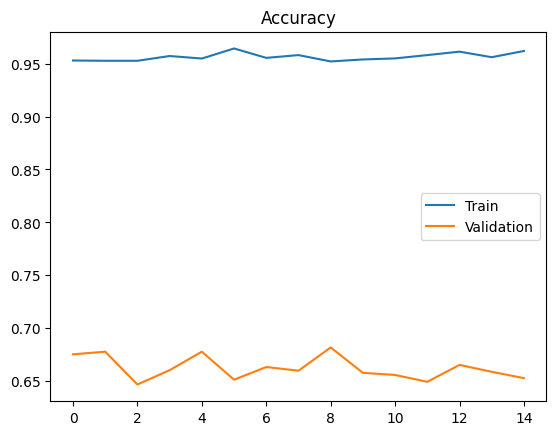

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Accuracy")
plt.show()

In [27]:
import numpy as np

pred = model.predict(X_test[:5])
pred_classes = np.argmax(pred, axis=1)

genres = np.load("genre_classes.npy")

for i in range(5):
    print("Predicted:", genres[pred_classes[i]])
    print("Actual:", genres[y_test[i]])
    print("------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
Predicted: metal
Actual: blues
------
Predicted: jazz
Actual: rock
------
Predicted: pop
Actual: pop
------
Predicted: hiphop
Actual: pop
------
Predicted: jazz
Actual: jazz
------
